# Module 3: Training Loop End-to-End Test

Runs the full REINFORCE learning pipeline on a **tiny** system (3x3 lattice, 3 atoms dropped, ~6 atoms in King's lattice connectivity) to verify that the policy can learn schedules approaching or exceeding the fixed adiabatic baseline.

This is a functional test, not a research run.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch

from config import (
    ProjectConfig, ControlsConfig, UDGConfig, HardwareSpecs,
    ParamKind, project_config_from_dict,
)
from graphs.unit_disk import generate_square_lattice_udg
from module1.policy import SchedulePolicy
from module1.base import FixedScheduleBaseline
from module2.braket_backend import BraketBackend
from module3.backend_adapter import make_reward_fn
from module3.interfaces import TrainingConfig
from module3.reinforce import reinforce_step

## 1. Build a tiny config (3x3, King's lattice, ~6 atoms)

Tiny graph: 6 nodes, 9 edges
Approx MIS size: 2


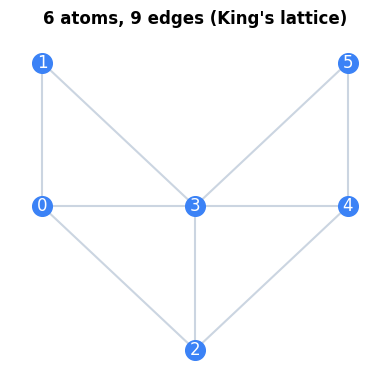

In [ ]:
# King's lattice: radius = sqrt(2) in units of spacing connects diagonals
# spacing = 5.0 um gives R_b/a ≈ 1.67 — blockades diagonals but NOT (2,0) neighbors,
# so the quantum MIS matches the graph-theoretic MIS on the King's lattice.
tiny_cfg = ProjectConfig(
    backend="bloqade",
    controls=ControlsConfig(
        T=4.0e-6,
        N_t=32,
        param_kind=ParamKind.pwl,
        learn_omega=False,
        architecture=2,
        omega_max=15.8,
        delta_min=-25.0,
        delta_max=25.0,
        n_delta_modes=6,
    ),
    udg=UDGConfig(
        nx=3, ny=3,
        spacing=5.0,
        radius=1.5,         # sqrt(2) < 1.5 — captures diagonals = King's graph
        dropout_rate=1/3,   # drop 3 of 9 = keep 6
        seed=42,
    ),
    hardware=HardwareSpecs(
        C6=5.42e6,
        omega_max=15.8,
        delta_min=-125.0,
        delta_max=125.0,
        t_ramp=0.4,
        t_onset=0.2,
    ),
)

# Verify graph is sensible
G_test, pos_test = generate_square_lattice_udg(tiny_cfg.udg)
print(f"Tiny graph: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")
print(f"Approx MIS size: {len(nx.algorithms.approximation.maximum_independent_set(G_test))}")

fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G_test, pos_test, ax=ax, with_labels=True,
        node_color="#3b82f6", node_size=200, font_color="white",
        edge_color="#cbd5e1", width=1.5)
ax.set_title(f"{G_test.number_of_nodes()} atoms, {G_test.number_of_edges()} edges (King's lattice)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Measure baseline p_MIS

In [20]:
N_SHOTS = 50

backend = BraketBackend(tiny_cfg, n_shots=N_SHOTS, backend_type="simulator", validate=True)
reward_fn = make_reward_fn(backend)

# Attach positions for the reward function
G_test.graph["positions"] = pos_test

baseline_model = FixedScheduleBaseline(tiny_cfg)
baseline_sched = baseline_model.make_schedule(G_test)

t0 = time.time()
baseline_result = backend.estimate_p_mis(baseline_sched, G_test, pos_test)
print(f"\nBaseline p_MIS = {baseline_result.p_mis:.2%} \u00b1 {baseline_result.std_err:.2%}  "
      f"({baseline_result.shots} shots, {time.time()-t0:.1f}s)")

BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s

Baseline p_MIS = 4.00% ± 2.77%  (50 shots, 1.1s)


## 3. Build training graph pool

Use a small pool of tiny graphs with different dropout seeds.

In [21]:
POOL_SIZE = 8
pool = []
for i in range(POOL_SIZE * 2):  # generate extras in case some have 0 edges
    udg_i = UDGConfig(
        nx=3, ny=3, spacing=5.0, radius=1.5,
        dropout_rate=1/3, seed=100 + i,
    )
    G, pos = generate_square_lattice_udg(udg_i)
    if G.number_of_edges() == 0:
        continue
    G.graph["positions"] = pos
    G.graph["seed"] = 100 + i
    pool.append(G)
    if len(pool) >= POOL_SIZE:
        break

print(f"Training pool: {len(pool)} graphs")
for G in pool:
    print(f"  seed={G.graph['seed']}: {G.number_of_nodes()}n, {G.number_of_edges()}e")

Training pool: 8 graphs
  seed=100: 6n, 8e
  seed=101: 6n, 10e
  seed=102: 6n, 5e
  seed=103: 6n, 10e
  seed=104: 6n, 7e
  seed=105: 6n, 9e
  seed=106: 6n, 9e
  seed=107: 6n, 10e


## 4. Run the REINFORCE training loop

Manual loop (not the full `TrainingOrchestrator`) so we can track and plot everything inline.

In [22]:
import random

TOTAL_STEPS = 40
BATCH_SIZE = 2
LR = 3e-4
EVAL_EVERY = 10

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

policy = SchedulePolicy(tiny_cfg, hidden_dim=32)
optimizer = torch.optim.Adam(policy.parameters(), lr=LR)
baseline_ema = {}

print(f"Policy: {sum(p.numel() for p in policy.parameters()):,} parameters")
print(f"Training: {TOTAL_STEPS} steps, batch={BATCH_SIZE}, lr={LR}")
print(f"Eval every {EVAL_EVERY} steps on {len(pool)} graphs")
print("=" * 70)

Policy: 15,730 parameters
Training: 40 steps, batch=2, lr=0.0003
Eval every 10 steps on 8 graphs


In [ ]:
train_history = []
eval_history = []

total_t0 = time.time()

for step in range(1, TOTAL_STEPS + 1):
    batch = random.sample(pool, min(BATCH_SIZE, len(pool)))

    t0 = time.time()
    metrics = reinforce_step(
        policy=policy,
        graphs=batch,
        backend_fn=reward_fn,
        optimizer=optimizer,
        baseline_ema=baseline_ema,
        entropy_coef=0.01,
        value_loss_coef=0.25,
        grad_clip=1.0,
    )
    metrics["step"] = step
    metrics["wall_time"] = time.time() - t0
    train_history.append(metrics)

    print(f"step {step:3d} | reward {metrics['mean_reward']:.3f} | "
          f"loss {metrics['loss']:.4f} | entropy {metrics['mean_entropy']:.3f} | "
          f"grad {metrics['grad_norm']:.3f} | {metrics['wall_time']:.1f}s")

    # Periodic evaluation
    if step % EVAL_EVERY == 0:
        policy.eval()
        learned_rewards, baseline_rewards = [], []
        for G in pool:
            sched_l = policy.make_schedule(G)
            r_l = reward_fn(G, sched_l)
            learned_rewards.append(r_l)

            sched_b = baseline_model.make_schedule(G)
            r_b = reward_fn(G, sched_b)
            baseline_rewards.append(r_b)
        policy.train()

        eval_entry = {
            "step": step,
            "learned_mean": np.mean(learned_rewards),
            "learned_std": np.std(learned_rewards),
            "baseline_mean": np.mean(baseline_rewards),
            "baseline_std": np.std(baseline_rewards),
        }
        eval_history.append(eval_entry)
        print(f"  EVAL | learned {eval_entry['learned_mean']:.3f} \u00b1 {eval_entry['learned_std']:.3f} | "
              f"baseline {eval_entry['baseline_mean']:.3f} \u00b1 {eval_entry['baseline_std']:.3f} | "
              f"improvement {eval_entry['learned_mean'] - eval_entry['baseline_mean']:+.3f}")

total_time = time.time() - total_t0
print(f"\nDone. Total wall time: {total_time/60:.1f} min")

BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
step   1 | reward 0.460 | loss 0.1307 | entropy 2.933 | grad 2.193 | 2.4s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
step   2 | reward 0.500 | loss 3.0363 | entropy 2.935 | grad 2.115 | 2.2s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.0 s
step   3 | reward 0.500 | loss -0.5996 | entropy 2.933 | grad 1.467 | 2.4s
BraketBackend: running LocalSimulator — 50 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 50 shots,

## 5. Learning curves

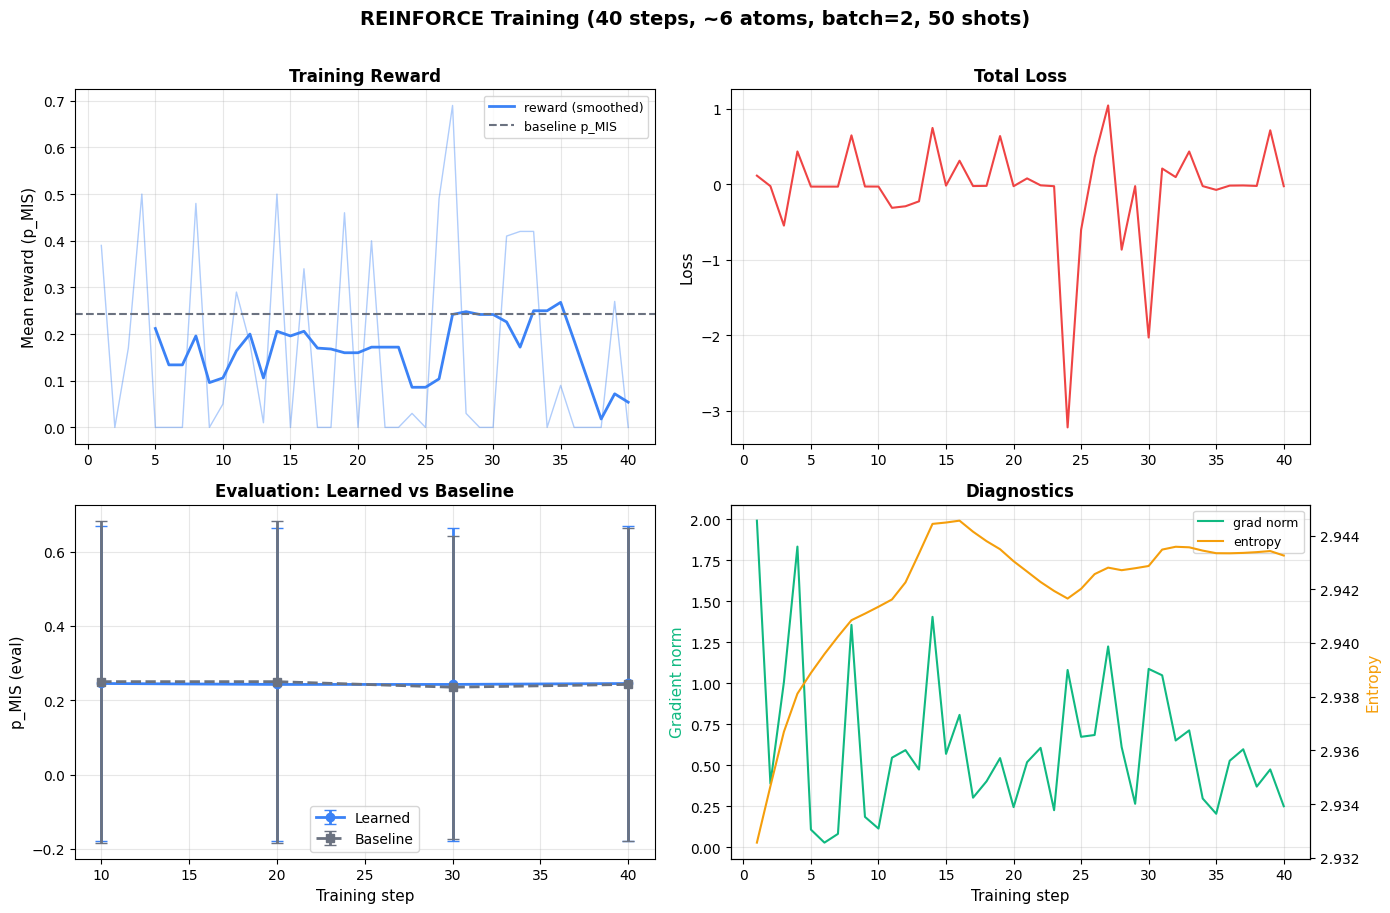

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

steps = [m["step"] for m in train_history]

# --- Panel 1: Training reward ---
ax = axes[0, 0]
rewards = [m["mean_reward"] for m in train_history]
ax.plot(steps, rewards, color="#3b82f6", alpha=0.4, linewidth=1)
# Smoothed
window = min(5, len(rewards))
if window > 1:
    smoothed = np.convolve(rewards, np.ones(window)/window, mode="valid")
    ax.plot(steps[window-1:], smoothed, color="#3b82f6", linewidth=2, label="reward (smoothed)")
# Baseline reference
if eval_history:
    ax.axhline(eval_history[-1]["baseline_mean"], color="#6b7280", linestyle="--",
               linewidth=1.5, label="baseline p_MIS")
ax.set_ylabel("Mean reward (p_MIS)", fontsize=11)
ax.set_title("Training Reward", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Panel 2: Loss ---
ax = axes[0, 1]
ax.plot(steps, [m["loss"] for m in train_history], color="#ef4444", linewidth=1.5)
ax.set_ylabel("Loss", fontsize=11)
ax.set_title("Total Loss", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# --- Panel 3: Eval learned vs baseline ---
ax = axes[1, 0]
if eval_history:
    e_steps = [e["step"] for e in eval_history]
    e_learned = [e["learned_mean"] for e in eval_history]
    e_learned_std = [e["learned_std"] for e in eval_history]
    e_baseline = [e["baseline_mean"] for e in eval_history]
    e_baseline_std = [e["baseline_std"] for e in eval_history]

    ax.errorbar(e_steps, e_learned, yerr=e_learned_std, color="#3b82f6",
                marker="o", capsize=4, linewidth=2, label="Learned")
    ax.errorbar(e_steps, e_baseline, yerr=e_baseline_std, color="#6b7280",
                marker="s", capsize=4, linewidth=2, linestyle="--", label="Baseline")
ax.set_ylabel("p_MIS (eval)", fontsize=11)
ax.set_xlabel("Training step", fontsize=11)
ax.set_title("Evaluation: Learned vs Baseline", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Panel 4: Gradient norm + entropy ---
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(steps, [m["grad_norm"] for m in train_history], color="#10b981", linewidth=1.5, label="grad norm")
ax2.plot(steps, [m["mean_entropy"] for m in train_history], color="#f59e0b", linewidth=1.5, label="entropy")
ax.set_ylabel("Gradient norm", fontsize=11, color="#10b981")
ax2.set_ylabel("Entropy", fontsize=11, color="#f59e0b")
ax.set_xlabel("Training step", fontsize=11)
ax.set_title("Diagnostics", fontsize=12, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")
ax.grid(alpha=0.3)

fig.suptitle(f"REINFORCE Training ({TOTAL_STEPS} steps, ~{G_test.number_of_nodes()} atoms, "
             f"batch={BATCH_SIZE}, {N_SHOTS} shots)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 6. Compare final schedules: learned vs baseline

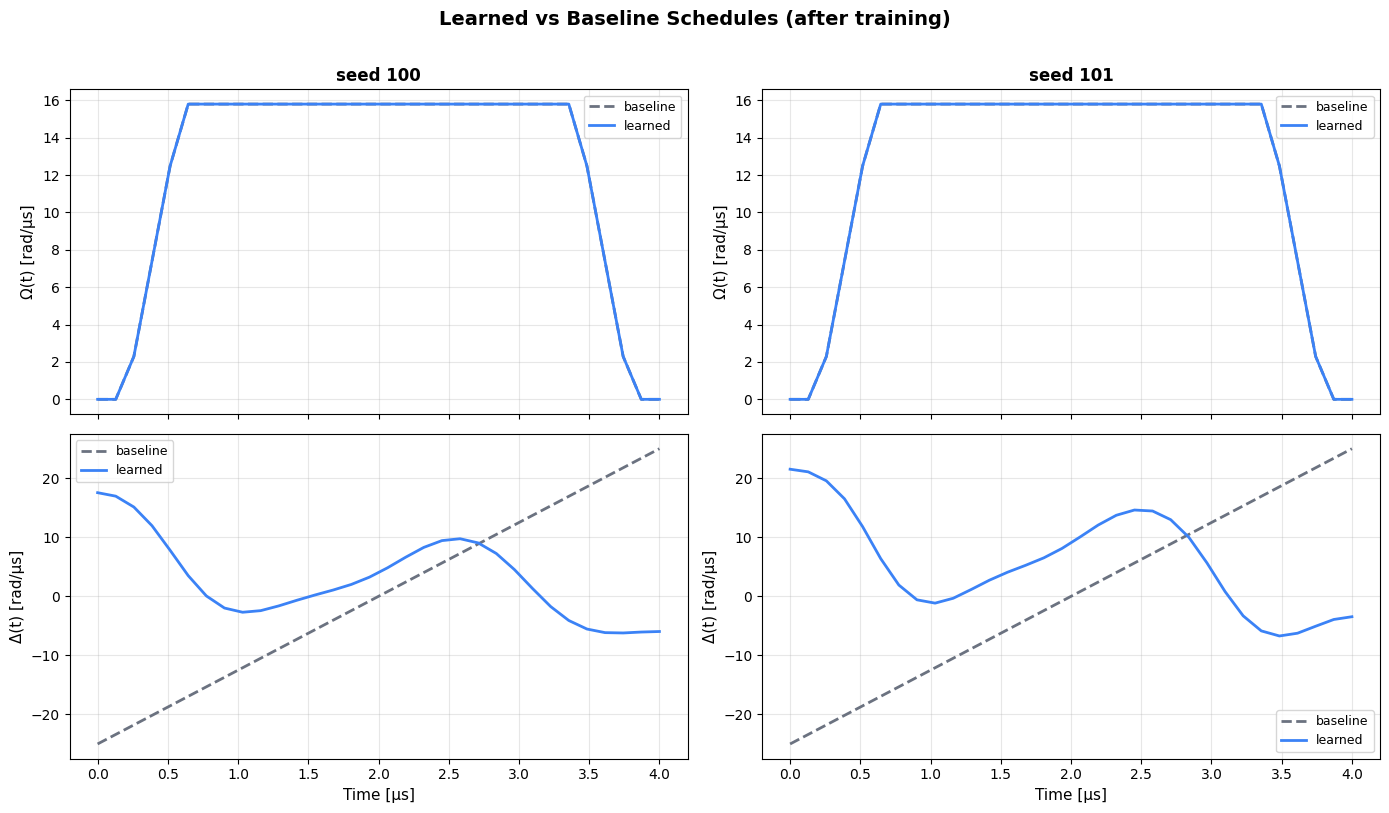

In [ ]:
t_us = np.linspace(0, tiny_cfg.controls.T * 1e6, tiny_cfg.controls.N_t)

policy.eval()
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for col, G in enumerate(pool[:2]):
    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)
    seed = G.graph.get("seed", "?")

    axes[0, col].plot(t_us, sched_b.omega, color="#6b7280", linewidth=2,
                      linestyle="--", label="baseline")
    axes[0, col].plot(t_us, sched_l.omega, color="#3b82f6", linewidth=2,
                      label="learned")
    axes[0, col].set_ylabel("\u03a9(t) [rad/\u00b5s]", fontsize=11)
    axes[0, col].set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    axes[0, col].legend(fontsize=9)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(t_us, sched_b.delta, color="#6b7280", linewidth=2,
                      linestyle="--", label="baseline")
    axes[1, col].plot(t_us, sched_l.delta, color="#3b82f6", linewidth=2,
                      label="learned")
    axes[1, col].set_ylabel("\u0394(t) [rad/\u00b5s]", fontsize=11)
    axes[1, col].set_xlabel("Time [\u00b5s]", fontsize=11)
    axes[1, col].legend(fontsize=9)
    axes[1, col].grid(alpha=0.3)

policy.train()

fig.suptitle("Learned vs Baseline Schedules (after training)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 7. Final evaluation with more shots

In [ ]:
# Re-evaluate with more shots for cleaner p_MIS estimates
N_SHOTS_FINAL = 200
backend_final = BraketBackend(tiny_cfg, n_shots=N_SHOTS_FINAL, backend_type="simulator", validate=True)

policy.eval()
print(f"Final evaluation ({N_SHOTS_FINAL} shots per graph, {len(pool)} graphs)")
print("=" * 60)

final_learned, final_baseline = [], []
for G in pool:
    pos = G.graph["positions"]
    seed = G.graph.get("seed", "?")

    sched_l = policy.make_schedule(G)
    r_l = backend_final.estimate_p_mis(sched_l, G, pos)
    final_learned.append(r_l.p_mis)

    sched_b = baseline_model.make_schedule(G)
    r_b = backend_final.estimate_p_mis(sched_b, G, pos)
    final_baseline.append(r_b.p_mis)

    print(f"seed {seed}: learned={r_l.p_mis:.1%}  baseline={r_b.p_mis:.1%}  "
          f"diff={r_l.p_mis - r_b.p_mis:+.1%}")

policy.train()

print(f"\nMean learned:  {np.mean(final_learned):.1%} \u00b1 {np.std(final_learned):.1%}")
print(f"Mean baseline: {np.mean(final_baseline):.1%} \u00b1 {np.std(final_baseline):.1%}")
print(f"Mean improvement: {np.mean(np.array(final_learned) - np.array(final_baseline)):+.1%}")

Final evaluation (200 shots per graph, 8 graphs)
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.5 s
seed 100: learned=0.0%  baseline=0.0%  diff=+0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
seed 101: learned=99.0%  baseline=99.0%  diff=+0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
seed 102: learned=0.0%  baseline=0.0%  diff=+0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radi

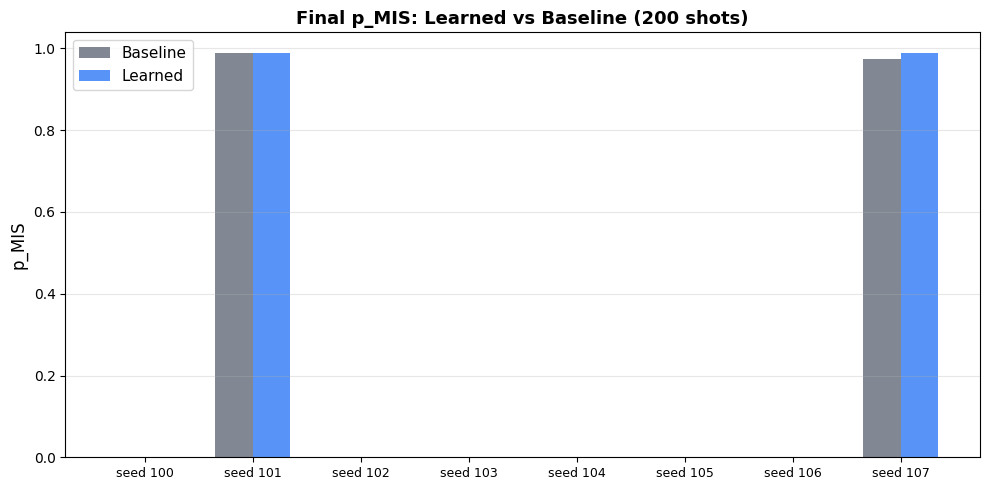

In [ ]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pool))
width = 0.35

ax.bar(x - width/2, final_baseline, width, color="#6b7280", alpha=0.85, label="Baseline")
ax.bar(x + width/2, final_learned, width, color="#3b82f6", alpha=0.85, label="Learned")

ax.set_xticks(x)
ax.set_xticklabels([f"seed {G.graph.get('seed', '?')}" for G in pool], fontsize=9)
ax.set_ylabel("p_MIS", fontsize=12)
ax.set_title(f"Final p_MIS: Learned vs Baseline ({N_SHOTS_FINAL} shots)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()

## 8. Dashboard: Graph + MIS solutions + Schedules + Measurement outcomes

For each graph in the pool, a single row shows:
1. The atom arrangement with all exact MIS solutions overlaid
2. The learned vs baseline schedules (Omega and Delta)
3. The top-10 most-frequently measured node sets, color-coded by whether they are independent sets

In [ ]:
from module2.graph_MIS_utils import get_all_MIS, check_independent_set
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# Pick a subset of graphs to display (up to 4 for readability)
display_graphs = pool[:4]
N_DISPLAY = len(display_graphs)

# Run high-shot simulations for both learned and baseline on each graph
# (reuses backend_final from cell above — 200 shots)
policy.eval()

display_data = []
for G in display_graphs:
    pos = G.graph["positions"]
    seed = G.graph.get("seed", "?")

    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)

    res_l = backend_final.estimate_p_mis(sched_l, G, pos)
    res_b = backend_final.estimate_p_mis(sched_b, G, pos)

    all_mis = get_all_MIS(G)

    display_data.append({
        "G": G, "pos": pos, "seed": seed,
        "sched_l": sched_l, "sched_b": sched_b,
        "res_l": res_l, "res_b": res_b,
        "all_mis": all_mis,
    })
    print(f"seed {seed}: {G.number_of_nodes()}n, {G.number_of_edges()}e, "
          f"{len(all_mis)} exact MIS solutions, "
          f"p_MIS learned={res_l.p_mis:.1%} baseline={res_b.p_mis:.1%}")

policy.train()

BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.0 s
seed 100: 6n, 8e, 3 exact MIS solutions, p_MIS learned=0.0% baseline=0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
seed 101: 6n, 10e, 5 exact MIS solutions, p_MIS learned=98.5% baseline=98.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.0 s
seed 102: 6n, 5e, 1 exact MIS solutions, p_MIS learned=0.0% baseline=0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 

SchedulePolicy(
  (encoder): GINEncoder(
    (layers): ModuleList(
      (0): GINConv(nn=Sequential(
        (0): Linear(in_features=7, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      ))
      (1-2): 2 x GINConv(nn=Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      ))
    )
  )
  (omega_head): AnalyticOmega()
  (delta_head): FourierDeltaHead(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=7, bias=True)
    )
  )
  (value_head): Sequential(
    (0): Linear(in_features=100, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

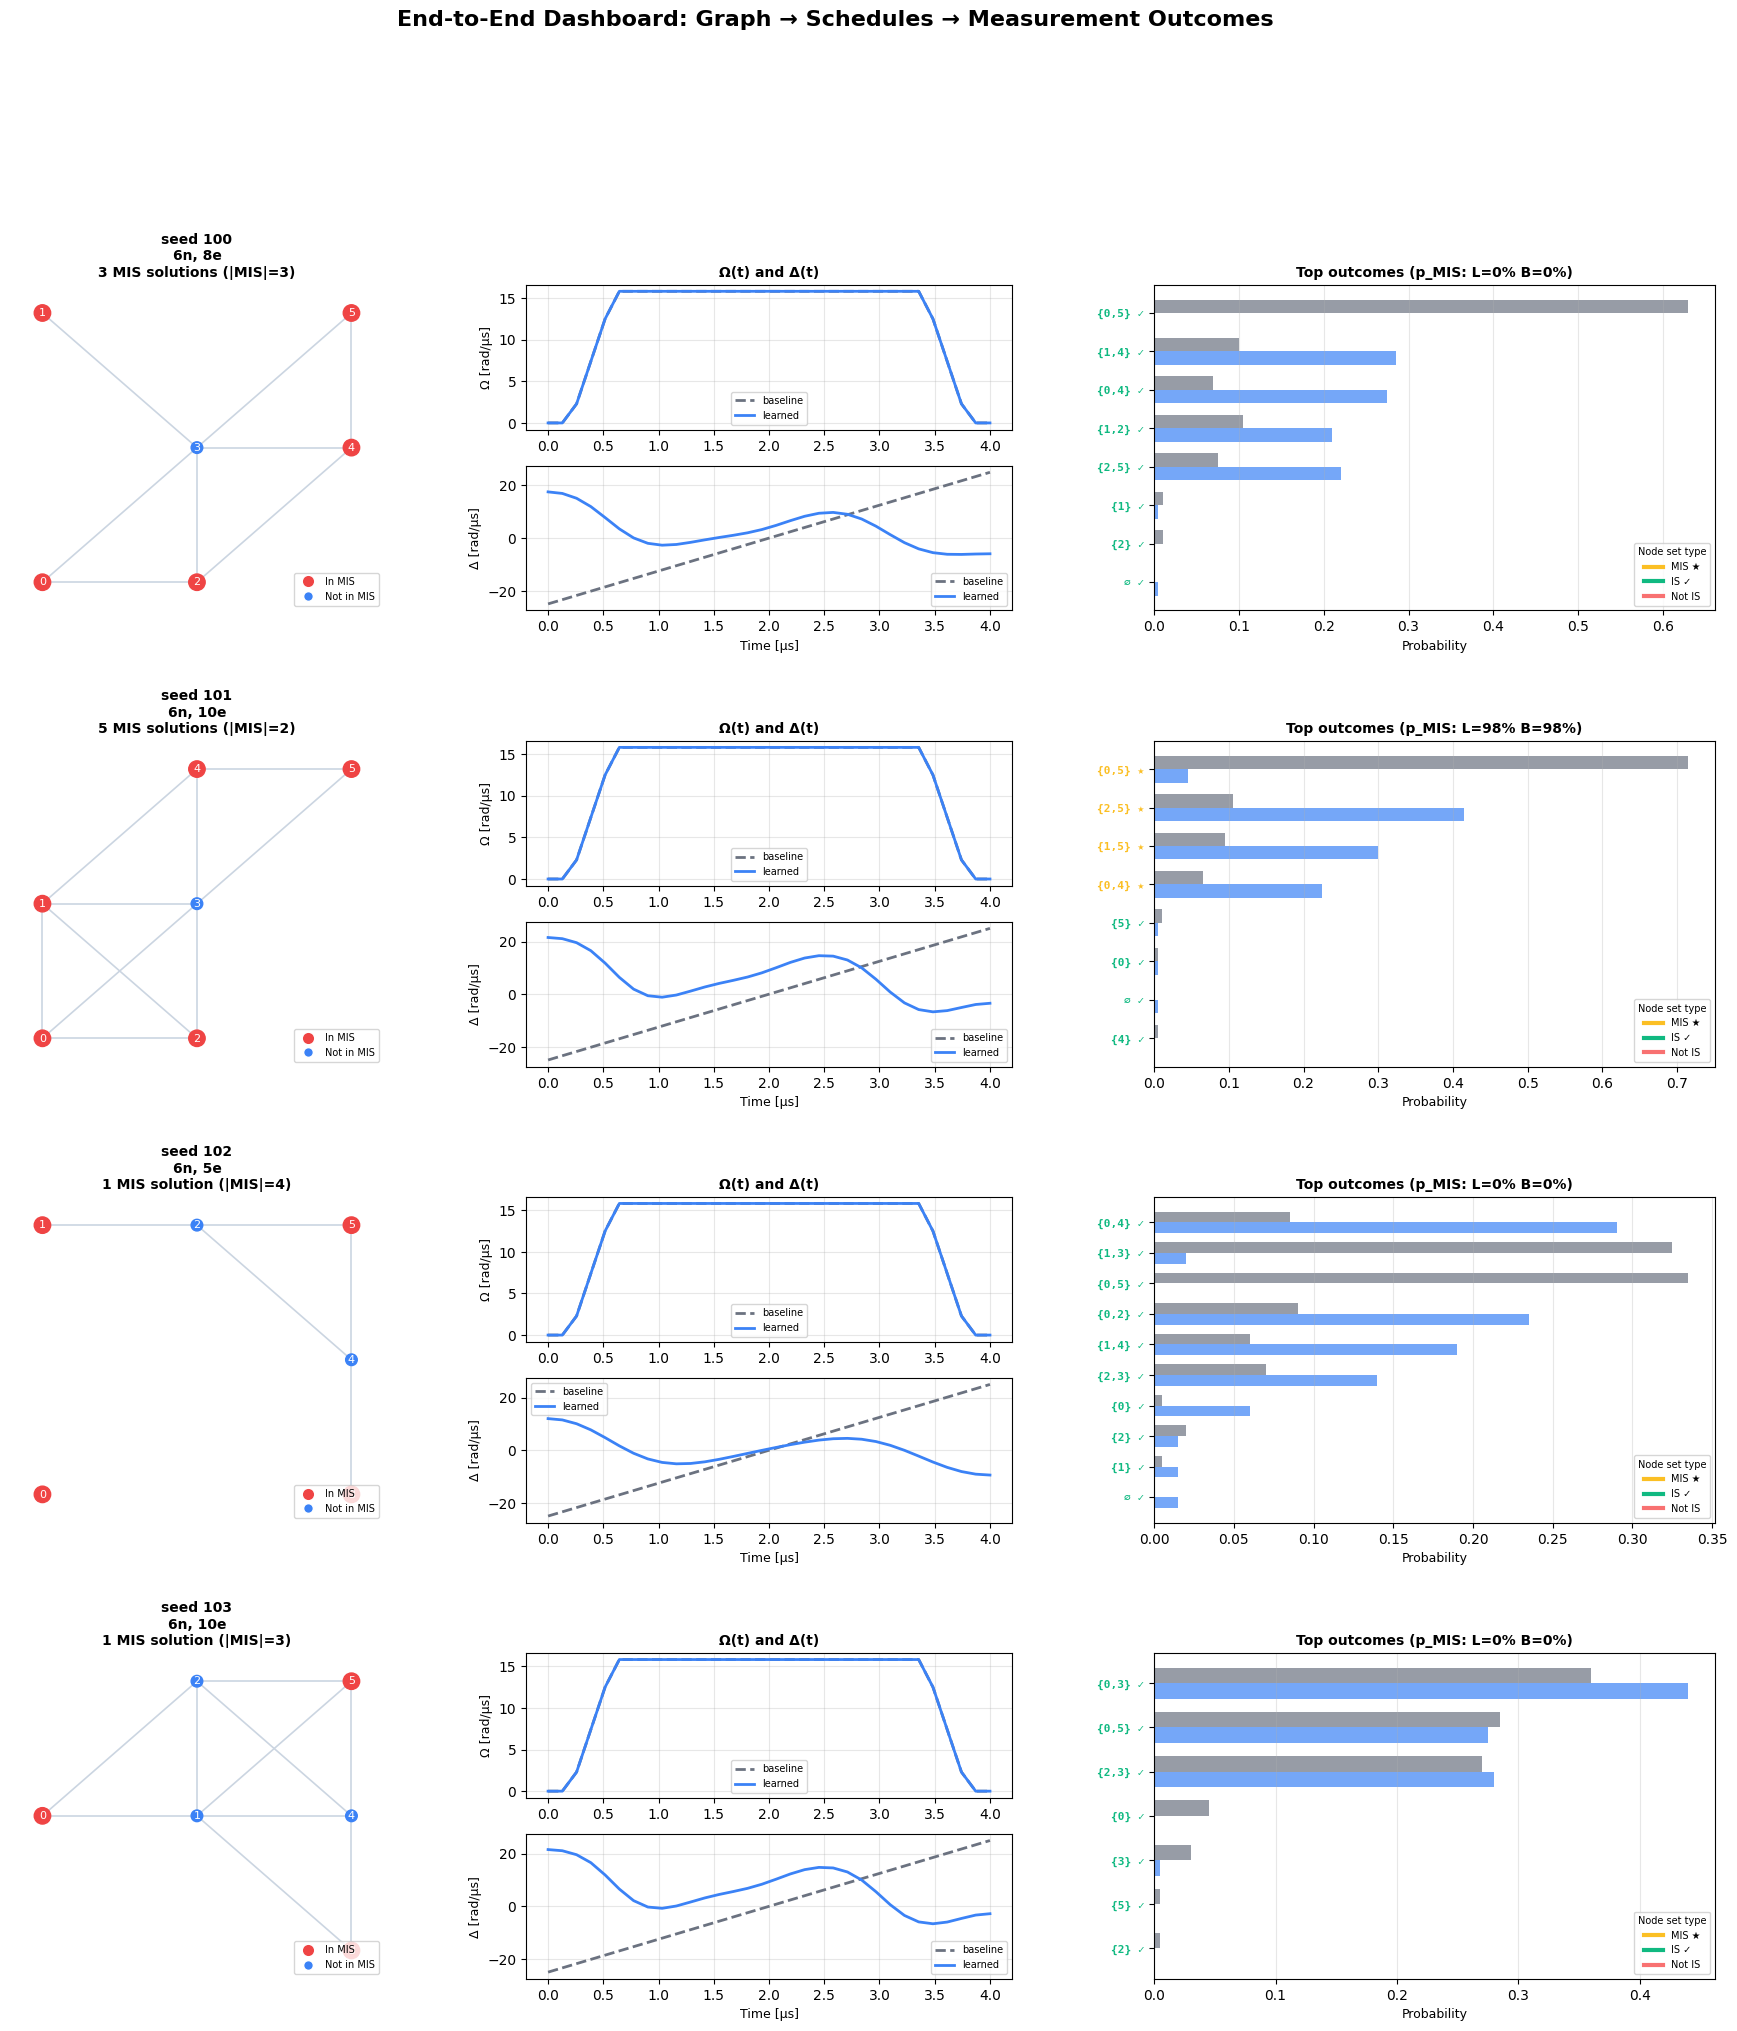

In [ ]:
def _top_node_sets(counts, n_atoms, top_k=10):
    """Convert bitstring counts to sorted list of (node_set, count) tuples."""
    entries = []
    for bs, cnt in counts.items():
        nodes = frozenset(i for i, c in enumerate(bs) if c == 'r')
        entries.append((nodes, cnt))
    entries.sort(key=lambda x: -x[1])
    # Merge duplicate node sets (shouldn't happen but be safe)
    merged = {}
    for ns, cnt in entries:
        merged[ns] = merged.get(ns, 0) + cnt
    result = sorted(merged.items(), key=lambda x: -x[1])
    return result[:top_k]


fig = plt.figure(figsize=(22, 5.5 * N_DISPLAY))
outer = gridspec.GridSpec(N_DISPLAY, 1, hspace=0.4, figure=fig)

t_us = np.linspace(0, tiny_cfg.controls.T * 1e6, tiny_cfg.controls.N_t)

for row, d in enumerate(display_data):
    G, pos, seed = d["G"], d["pos"], d["seed"]
    all_mis = d["all_mis"]
    sched_l, sched_b = d["sched_l"], d["sched_b"]
    res_l, res_b = d["res_l"], d["res_b"]

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 3, subplot_spec=outer[row],
        wspace=0.3, hspace=0.25,
        width_ratios=[1, 1.3, 1.5],
    )

    # ── Column 0: Graph with MIS solutions ──
    ax_graph = fig.add_subplot(inner[:, 0])
    mis_union = set()
    for s in all_mis:
        mis_union |= s
    node_list = sorted(G.nodes())
    nc = ["#ef4444" if n in mis_union else "#3b82f6" for n in node_list]
    ns = [140 if n in mis_union else 70 for n in node_list]
    nx.draw(G, pos, ax=ax_graph, with_labels=True, nodelist=node_list,
            node_color=nc, node_size=ns, font_size=8, font_color="white",
            edge_color="#cbd5e1", width=1.2)
    ax_graph.set_title(
        f"seed {seed}\n{G.number_of_nodes()}n, {G.number_of_edges()}e\n"
        f"{len(all_mis)} MIS solution{'s' if len(all_mis) != 1 else ''} "
        f"(|MIS|={len(all_mis[0])})",
        fontsize=10, fontweight="bold",
    )
    legend_els = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444',
               markersize=9, label='In MIS'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3b82f6',
               markersize=7, label='Not in MIS'),
    ]
    ax_graph.legend(handles=legend_els, fontsize=7, loc="lower right")

    # ── Column 1: Schedules ──
    ax_omega = fig.add_subplot(inner[0, 1])
    ax_omega.plot(t_us, sched_b.omega, color="#6b7280", linewidth=2,
                  linestyle="--", label="baseline")
    ax_omega.plot(t_us, sched_l.omega, color="#3b82f6", linewidth=2,
                  label="learned")
    ax_omega.set_ylabel("\u03a9 [rad/\u00b5s]", fontsize=9)
    ax_omega.set_title("\u03a9(t) and \u0394(t)", fontsize=10, fontweight="bold")
    ax_omega.legend(fontsize=7)
    ax_omega.grid(alpha=0.3)

    ax_delta = fig.add_subplot(inner[1, 1], sharex=ax_omega)
    ax_delta.plot(t_us, sched_b.delta, color="#6b7280", linewidth=2,
                  linestyle="--", label="baseline")
    ax_delta.plot(t_us, sched_l.delta, color="#3b82f6", linewidth=2,
                  label="learned")
    ax_delta.set_ylabel("\u0394 [rad/\u00b5s]", fontsize=9)
    ax_delta.set_xlabel("Time [\u00b5s]", fontsize=9)
    ax_delta.legend(fontsize=7)
    ax_delta.grid(alpha=0.3)

    # ── Column 2: Top-10 measurement outcomes ──
    ax_meas = fig.add_subplot(inner[:, 2])

    total_shots = sum(res_l.counts.values())
    top_l = _top_node_sets(res_l.counts, G.number_of_nodes(), top_k=10)
    top_b = _top_node_sets(res_b.counts, G.number_of_nodes(), top_k=10)

    # Combine unique node sets from both, sort by max frequency
    all_sets = {}
    for ns, cnt in top_l:
        all_sets[ns] = all_sets.get(ns, {"learned": 0, "baseline": 0})
        all_sets[ns]["learned"] = cnt / total_shots
    for ns, cnt in top_b:
        all_sets[ns] = all_sets.get(ns, {"learned": 0, "baseline": 0})
        all_sets[ns]["baseline"] = cnt / total_shots
    sorted_sets = sorted(all_sets.items(),
                         key=lambda x: -(x[1]["learned"] + x[1]["baseline"]))[:10]

    labels = []
    learned_probs = []
    baseline_probs = []
    bar_edge_colors = []
    for ns, freqs in sorted_sets:
        node_str = "{" + ",".join(str(n) for n in sorted(ns)) + "}" if ns else "\u2205"
        is_IS = check_independent_set(
            "".join("r" if i in ns else "g" for i in range(G.number_of_nodes())), G)
        is_MIS = ns in [frozenset(s) for s in all_mis]
        suffix = " \u2605" if is_MIS else (" \u2713" if is_IS else "")
        labels.append(node_str + suffix)
        learned_probs.append(freqs.get("learned", 0))
        baseline_probs.append(freqs.get("baseline", 0))
        bar_edge_colors.append("#fbbf24" if is_MIS else ("#10b981" if is_IS else "#f87171"))

    y = np.arange(len(labels))
    bar_h = 0.35
    ax_meas.barh(y - bar_h/2, baseline_probs, bar_h, color="#6b7280",
                 alpha=0.7, label="baseline")
    ax_meas.barh(y + bar_h/2, learned_probs, bar_h, color="#3b82f6",
                 alpha=0.7, label="learned")

    # Color-code the labels
    ax_meas.set_yticks(y)
    ax_meas.set_yticklabels(labels, fontsize=8, fontfamily="monospace")
    for tick_label, ec in zip(ax_meas.get_yticklabels(), bar_edge_colors):
        tick_label.set_color(ec)
        tick_label.set_fontweight("bold")

    ax_meas.invert_yaxis()
    ax_meas.set_xlabel("Probability", fontsize=9)
    ax_meas.set_title(
        f"Top outcomes (p_MIS: L={res_l.p_mis:.0%} B={res_b.p_mis:.0%})",
        fontsize=10, fontweight="bold")
    ax_meas.legend(fontsize=7, loc="lower right")
    ax_meas.grid(axis="x", alpha=0.3)

    # Legend for color coding
    legend_meas = [
        Line2D([0], [0], color="#fbbf24", linewidth=3, label="MIS \u2605"),
        Line2D([0], [0], color="#10b981", linewidth=3, label="IS \u2713"),
        Line2D([0], [0], color="#f87171", linewidth=3, label="Not IS"),
    ]
    ax_meas.legend(handles=legend_meas, fontsize=7, loc="lower right",
                   title="Node set type", title_fontsize=7)

fig.suptitle("End-to-End Dashboard: Graph \u2192 Schedules \u2192 Measurement Outcomes",
             fontsize=16, fontweight="bold", y=1.005)
plt.show()